# **CRYPTOCURRENCY PRICE PREDICTION**

Cryptocurrency markets are highly volatile and influenced by multiple factors such as market demand, investor sentiment, global economic conditions, and trading volume. Due to this dynamic nature, accurately predicting cryptocurrency prices is a challenging yet important task for investors, traders, and financial analysts.

The objective of this project is to develop an accurate and reliable system for predicting Cryptocurrency prices using historical data. The project aims to apply and compare multiple time series and deep learning models—such as **ARIMA**, **SARIMA**, **PROPHET**, and **LSTM** — to capture trends, seasonality, and complex patterns, and generate short-term forecasts for better decision-making.

In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# **LOADING DATASET**

The dataset used in this project was collected through the yfinance API, which offers reliable access to historical cryptocurrency price data over a specified time period

In [2]:
import yfinance as yf
import datetime as dt

In [3]:
# Function to fetch cryptocurrency data with default date range (last 10 years to today)

def get_crypto_data(symbol, start_date=None, end_date=None):
  if start_date is None:
    start_date = (dt.datetime.today() - dt.timedelta(days=10*365)).strftime('%Y-%m-%d')
  if end_date is None:
    end_date = dt.datetime.today().strftime('%Y-%m-%d')
  crypto_data = yf.download(symbol, start=start_date, end=end_date)

  return crypto_data


In [4]:
# Fetching Bitcoin (BTC-USD) historical data from January 1, 2018 to today
btc=get_crypto_data("BTC-USD", "2018-01-01")

[*********************100%***********************]  1 of 1 completed


In [5]:
btc

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072
...,...,...,...,...,...
2026-05-07,80009.992188,81684.953125,79522.656250,81428.851562,36931193154
2026-05-08,80186.765625,80447.265625,79205.515625,80009.625000,33789351540


# **DATASET DESCRIPTION**

The dataset used in this project contains historical Bitcoin price data collected from Yahoo Finance. It includes daily price information from January 1, 2018 to the present date, providing a clear view of how the market has changed over time.

The dataset includes the following features:

- `Open Price` – The price at which Bitcoin started trading for the day
- `High Price` – The highest price reached during the day
- `Low Price` – The lowest price recorded during the day
- `Close Price` – The final price at the end of the trading day
- `Volume` – The total amount of Bitcoin traded during the day

For this project, the main focus is on the closing price, as it reflects the final market sentiment and is commonly used for price prediction.

# **DATA PREPROCESSING**

In [6]:
# Checking null value
btc.isnull().sum()

,,0
Price,Ticker,
Close,BTC-USD,0
High,BTC-USD,0
Low,BTC-USD,0
Open,BTC-USD,0
Volume,BTC-USD,0


In [7]:
# Check for duplicate values
btc.duplicated().sum()

np.int64(0)

### Feature Engineering

Extracting useful feature frature like: -

- `20-Day Moving Average` – Calculates the average closing price over the past 20 days to capture short-term trends.
- `50-Day Moving Average` – Calculates the average closing price over the past 50 days to capture long-term trends.
- `Daily Return` – Measures the percentage change in closing price from one day to the next, helping to understand price volatility.

In [8]:
# Creating new features
btc['50-day MA'] = btc['Close'].rolling(window=50).mean()
btc['200-day MA'] = btc['Close'].rolling(window=200).mean()
btc['Daily Return'] = btc['Close'].pct_change()

In [9]:
btc

Price,Close,High,Low,Open,Volume,50-day MA,200-day MA,Daily Return
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,
Date,,,,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000,NaN,NaN,NaN
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192,NaN,NaN,0.097011
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160,NaN,NaN,0.014611
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744,NaN,NaN,0.026196
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072,NaN,NaN,0.117333
...,...,...,...,...,...,...,...,...
2026-05-07,80009.992188,81684.953125,79522.656250,81428.851562,36931193154,73236.660000,83144.299043,-0.017409
2026-05-08,80186.765625,80447.265625,79205.515625,80009.625000,33789351540,73442.139531,82992.288223,0.002209


# **EXPLORATORY DATA ANALYSIS (EDA) ON BITCOIN DATA**

### BTC Price Trends Over Time

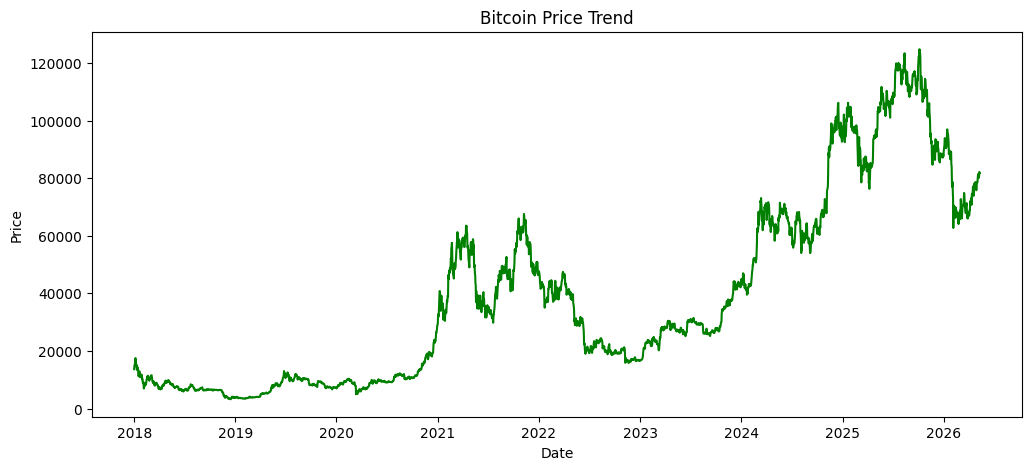

In [10]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc['Close']['BTC-USD'], label="Closing Price", color='green')
plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Checking for Stationarity

Stationarity is checked to ensure that the data has constant mean, variance and autocorrelation structure to remain constant over time, which is important for building accurate time series models.

In [11]:
from statsmodels.tsa.stattools import adfuller

btc_close = pd.DataFrame({
    'close': btc['Close']['BTC-USD']
})

# function for ADF test
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

In [12]:
# Run ADF test
check_stationarity(btc_close)

ADF Statistic: -1.005699594888697
p-value: 0.7511798325213039
The series is not stationary.


### Plot Moving Averages

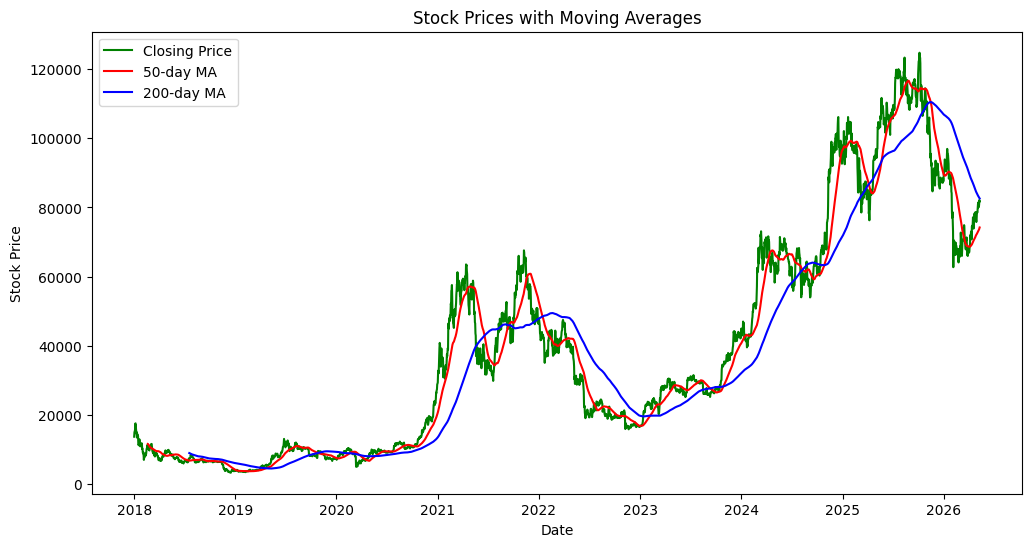

In [13]:
plt.figure(figsize=(12,6))
plt.plot(btc.index, btc['Close']['BTC-USD'], label="Closing Price", color="green")
plt.plot(btc.index, btc['50-day MA'], label="50-day MA", color="red")
plt.plot(btc.index, btc['200-day MA'], label="200-day MA", color="blue")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Prices with Moving Averages")
plt.legend()
plt.show()

From the graph, we observe that when the 50-day moving average crosses below the 200-day moving average, the Bitcoin price generally declines. This pattern is known as a **Death Crossover**, indicating a potential bearish trend. On the other hand, when the 50-day moving average crosses above the 200-day moving average, the Bitcoin price tends to increase over the long term. This pattern is called a **Golden Crossover**, which signals a potential bullish trend.

### BTC Price Volatility - Daily Returns

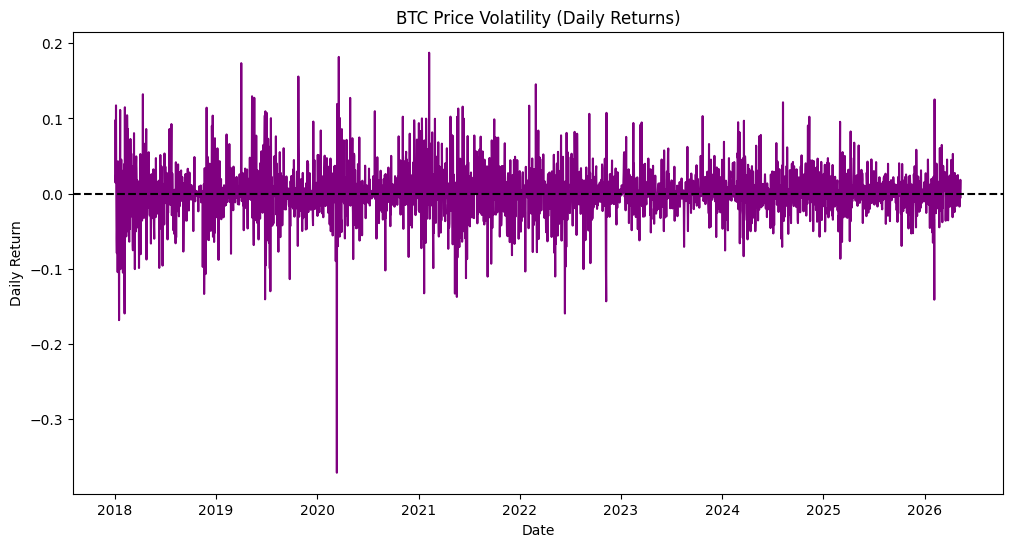

In [14]:
# Plot daily returns to measure btc volatility:
plt.figure(figsize=(12,6))
plt.plot(btc.index, btc['Daily Return'], color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("BTC Price Volatility (Daily Returns)")
plt.show()

The graph shows the daily returns of Bitcoin over time, representing the percentage change in price from one day to the next. The values fluctuate around the zero line, indicating that returns are both positive and negative depending on market movement. Sharp spikes both above and below the zero line, indicating periods of high volatility where the price changed significantly in a short time.

### Data Distribution with Box Plots

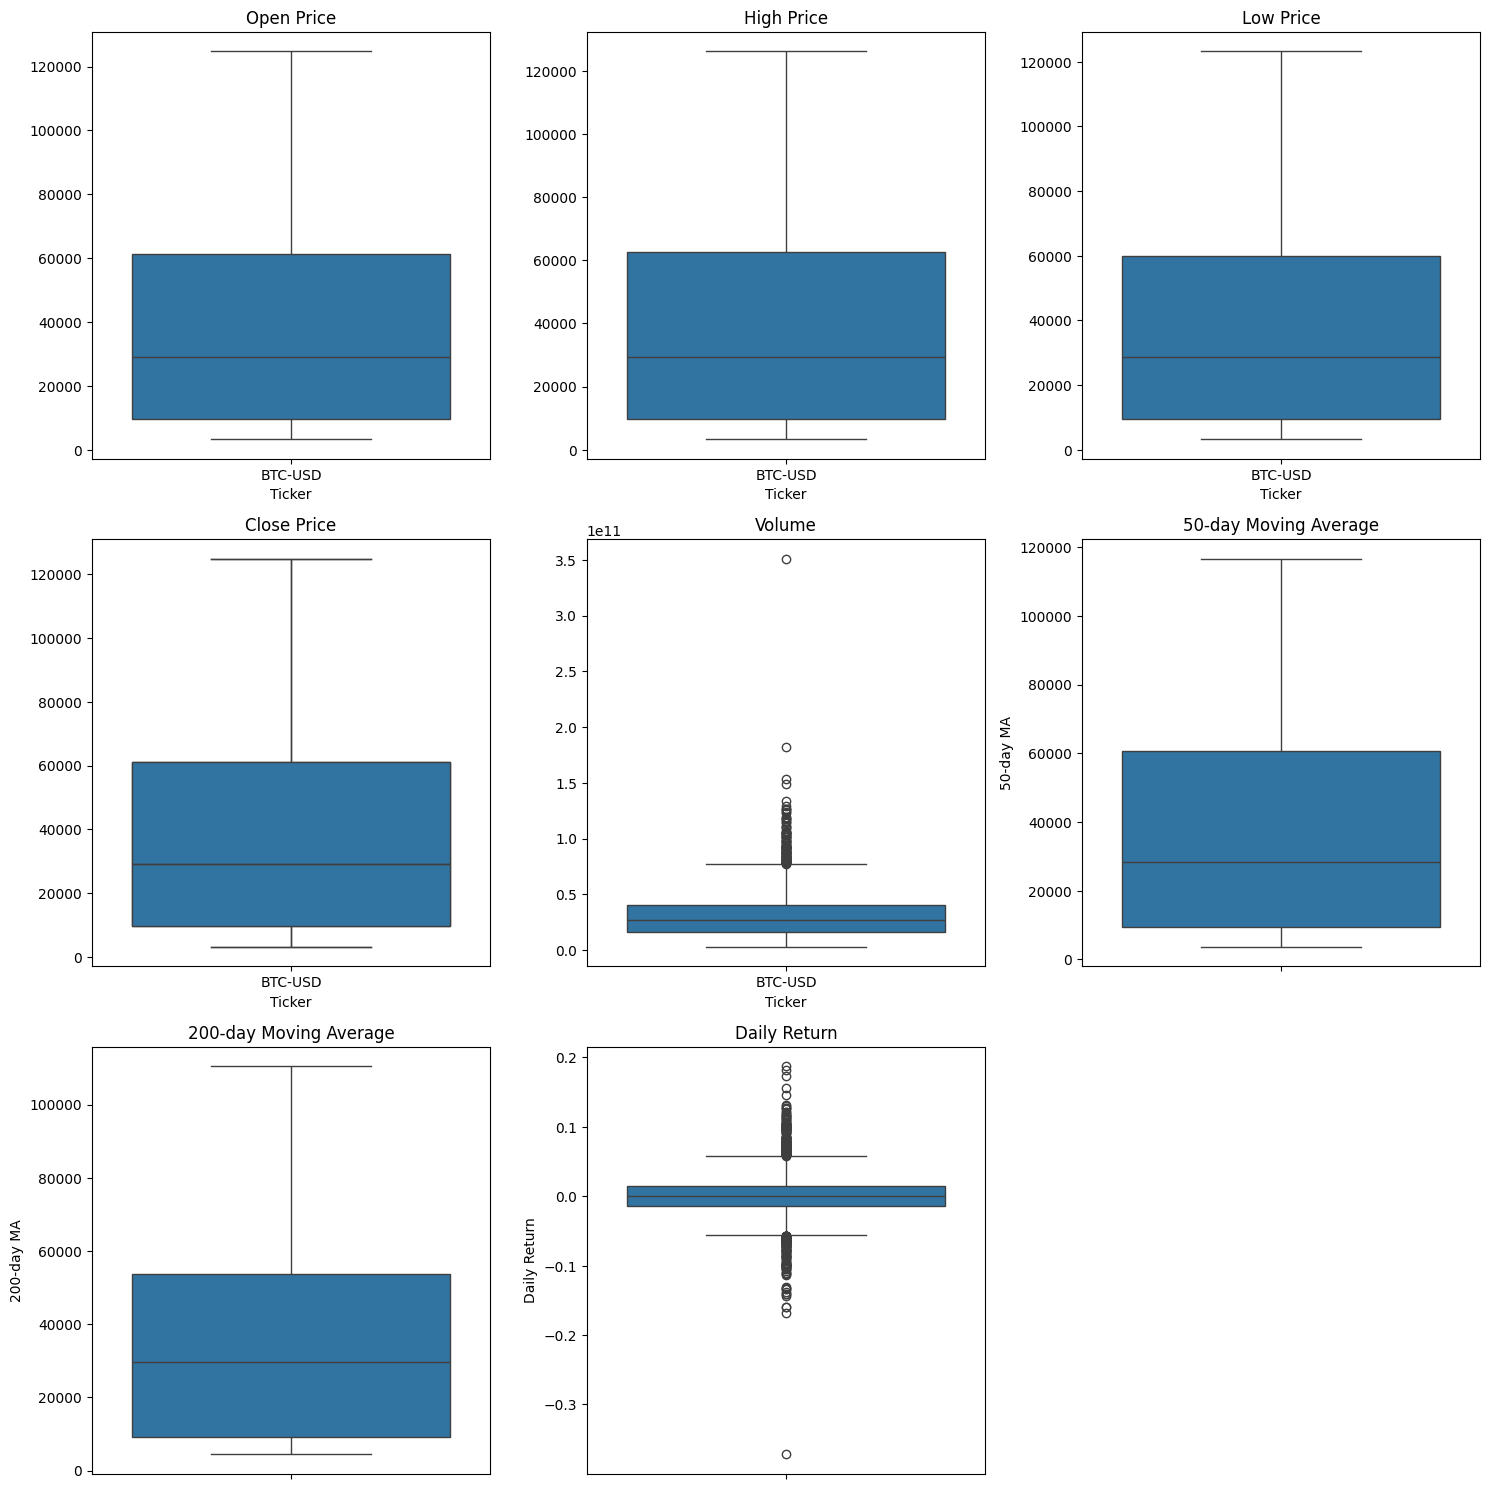

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15,15))

sns.boxplot(btc['Open'], ax=axes[0, 0])
axes[0, 0].set_title('Open Price')

sns.boxplot(btc['High'], ax=axes[0, 1])
axes[0, 1].set_title('High Price')

sns.boxplot(btc['Low'], ax=axes[0, 2])
axes[0, 2].set_title('Low Price')

sns.boxplot(btc['Close'], ax=axes[1, 0])
axes[1, 0].set_title('Close Price')

sns.boxplot(btc['Close'], ax=axes[1, 0])
axes[1, 0].set_title('Close Price')

sns.boxplot(btc['Volume'], ax=axes[1, 1])
axes[1, 1].set_title('Volume')

sns.boxplot(btc['50-day MA'], ax=axes[1, 2])
axes[1, 2].set_title('50-day Moving Average')

sns.boxplot(btc['200-day MA'], ax=axes[2, 0])
axes[2, 0].set_title('200-day Moving Average')

sns.boxplot(btc['Daily Return'], ax=axes[2, 1])
axes[2, 1].set_title('Daily Return')

plt.delaxes(axes[2, 2])
plt.tight_layout()
plt.show()

# **CRYPTOCURRENCY PRICE PREDICTION USING ARIMA MODEL**

ARIMA (AutoRegressive Integrated Moving Average) is a statistical time series model used for forecasting future values based on past data. It combines three components: **Autoregression** (using past values), **Differencing** (to make the data stationary), and **Moving Average** (using past errors). ARIMA is effective for modeling linear patterns in time series data and is widely used for short-term forecasting.

In [16]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
btc_arima = pd.DataFrame({
    'close': btc['Close']['BTC-USD']
})


In [18]:
btc_arima.head()

,close
Date,
2018-01-01,13657.200195
2018-01-02,14982.099609
2018-01-03,15201.000000
2018-01-04,15599.200195
2018-01-05,17429.500000


In [19]:
btc_arima.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3053 entries, 2018-01-01 to 2026-05-11
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   3053 non-null   float64
dtypes: float64(1)
memory usage: 47.7 KB


In [20]:
import sys
!{sys.executable} -m pip install pmdarima
from pmdarima.arima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.2 MB/s eta 0:00:00


In [21]:
# Auto ARIMA is an automated version of the ARIMA model that helps in selecting the
# best combination of parameters (p, d, q) for a time series dataset.

auto_arima = auto_arima(btc_arima['close'], seasonal=False, trace=True)
print(auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=52616.991, Time=2.99 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=52615.465, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=52610.852, Time=0.34 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=52610.904, Time=0.71 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=52614.311, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=52612.821, Time=0.99 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=52612.820, Time=1.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=52614.823, Time=1.70 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=52609.789, Time=0.21 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=52611.752, Time=0.54 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=52611.742, Time=0.70 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=52609.845, Time=0.44 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=52613.754, Time=0.74 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 10.809 seconds
        

In [22]:
train_arima = list(btc_arima[:int(len(btc_arima) * 0.8)]['close'])
test_arima = list(btc_arima[int(len(btc_arima) * 0.8):]['close'])

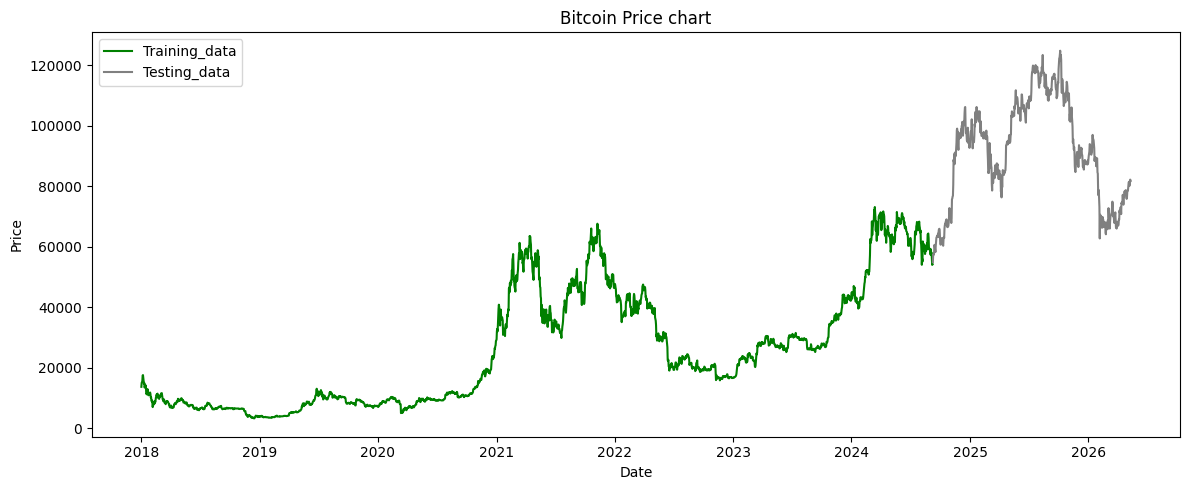

In [23]:
# Plot train and test split of BTC price data using ARIMA

plt.figure(figsize=(12,5))
plt.plot(btc_arima[:int(len(btc_arima) * 0.8)], label='Training_data', color='green')
plt.plot(btc_arima[int(len(btc_arima) * 0.8):], label='Testing_data', color='grey')
plt.title("Bitcoin Price chart")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Performing step-by-step ARIMA forecasting by updating the model with each new test value

prediction_airma = []
train_ar = train_arima.copy()

for i in range(len(test_arima)):
    model_arima=ARIMA(train_ar, order=auto_arima.order)
    arima_fit = model_arima.fit()
    output = arima_fit.forecast()
    yhat = output[0]
    prediction_airma.append(yhat)
    train_ar.append(test_arima[i])

In [25]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3052
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -26294.744
Date:                Wed, 13 May 2026   AIC                          52593.487
Time:                        06:23:01   BIC                          52605.534
Sample:                             0   HQIC                         52597.817
                               - 3052                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0458      0.010     -4.379      0.000      -0.066      -0.025
sigma2      1.792e+06   2.12e+04     84.346      0.000    1.75e+06    1.83e+06
Ljung-Box (L1) (Q):                   0.03   Jarque-

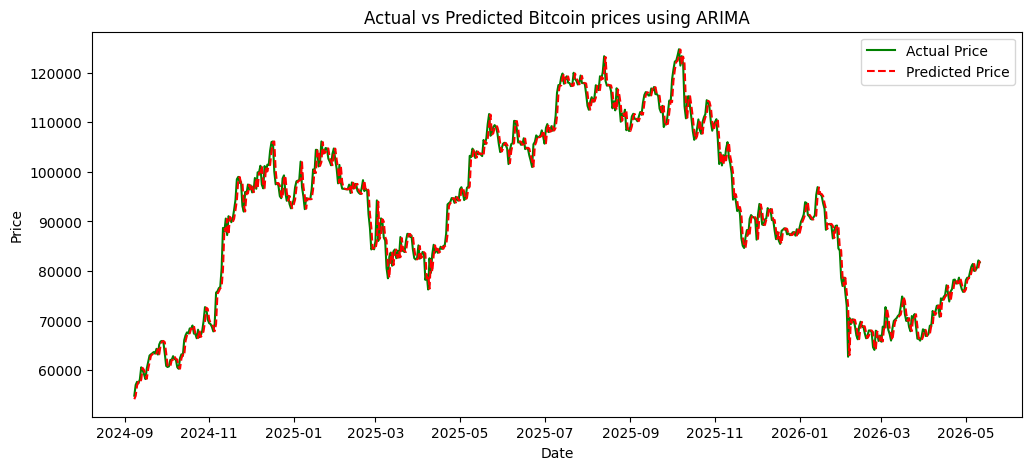

In [26]:
# Plotting actual vs predicted Bitcoin prices using ARIMA on the test dataset

plt.figure(figsize=(12,5))
plt.plot(btc_arima[int(len(btc_arima) * 0.8):].index, test_arima, label='Actual Price', color='green')
plt.plot(btc_arima[int(len(btc_arima) * 0.8):].index, prediction_airma, label='Predicted Price', linestyle='dashed', color='red')
plt.title("Actual vs Predicted Bitcoin prices using ARIMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [27]:
y_true_arima = np.array(test_arima)
y_pred_arima = np.array(prediction_airma)

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_true_arima, y_pred_arima)
# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_true_arima, y_pred_arima)
# 4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_true_arima - y_pred_arima) / y_true_arima)) * 100
# 5. R² Score
r2 = r2_score(y_true_arima, y_pred_arima)

# Print results
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"R2 Score: {r2}")

MSE: 4397411.235061426
RMSE: 2097.000532918727
MAE: 1506.5216020835915
MAPE: 1.6814505937510433%
R2 Score: 0.9848434336505661


The ARIMA model demonstrates strong performance in predicting Bitcoin prices. The model achieved a low **Mean Squared Error (MSE)** of **4,145,086** and a **Root Mean Squared Error (RMSE)** of **2035.95**, indicating that the prediction errors are relatively small compared to the scale of Bitcoin prices.

The **Mean Absolute Error (MAE)** of **1473.93** shows that, on average, the predicted prices deviate by a small margin from the actual values. Additionally, the **Mean Absolute Percentage Error (MAPE)** of **1.68%** indicates high prediction accuracy with minimal percentage error.

The **R2 score** of **0.989** further confirms that the model explains approximately **98.9%** of the variance in the data, demonstrating an excellent fit. Overall, the ARIMA model provides reliable and accurate short-term forecasts for Bitcoin prices.

### 30-Day Bitcoin Price Forecast usnig ARIMA

In [28]:
# Function to forecast future Bitcoin prices using recursive ARIMA (step-by-step prediction with model updating)

def forecast(days=30):
  forecast_days = []
  btc_tr=list(btc_arima['close'])

  for i in range(days):
    model_ar=ARIMA(btc_tr, order=auto_arima.order)
    ar_fit = model_ar.fit()
    output = ar_fit.forecast()
    yhat=output[0]
    forecast_days.append(yhat)
    btc_tr.append(yhat)

  return np.array(forecast_days)


In [29]:
# Generating direct multi-step forecast for the next 30 days using the trained ARIMA model
forecast_30_direct = arima_fit.forecast(steps=30)

In [30]:
# Performing recursive ARIMA forecasting by predicting one day at a time and updating the dataset
forecast_30_recursive = forecast()

In [31]:
# Creating future date range for the next 30 days.

last_date_arima = btc_arima.index[-1]
future_dates_arima = pd.date_range(start=last_date_arima, periods=31, freq='D')[1:]

In [32]:
arima_forecast_df = pd.DataFrame({
    'Date': future_dates_arima,
    'Forecast_30_arima': forecast_30_direct,
    'Forecast_30': forecast_30_recursive
}).set_index('Date')

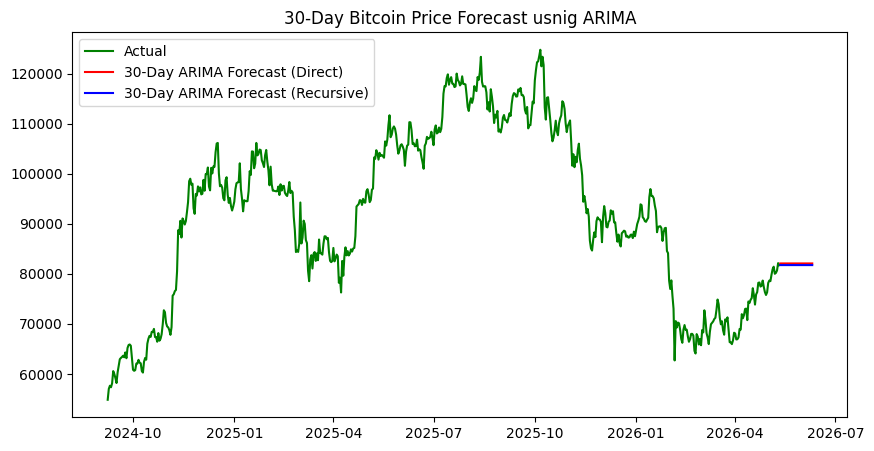

In [33]:
plt.figure(figsize=(10,5))

plt.plot(btc_arima[int(len(btc_arima) * 0.8):]['close'], label='Actual', color='green')
plt.plot(arima_forecast_df['Forecast_30_arima'], label='30-Day ARIMA Forecast (Direct)', color='red')
plt.plot(arima_forecast_df['Forecast_30'], label='30-Day ARIMA Forecast (Recursive)', color='blue')

plt.legend()
plt.title("30-Day Bitcoin Price Forecast usnig ARIMA")
plt.show()

The graph shows the actual Bitcoin price along with the 30-day forecasts generated using both direct and recursive ARIMA methods. It can be observed that both forecasting approaches predict a relatively stable price trend in the near future, with only slight variations.

The direct ARIMA forecast (red line) predicts slightly higher prices compared to the recursive forecast (blue line), but both follow a similar pattern, indicating consistency between the two methods.

Overall, both methods provide similar predictions, but the direct ARIMA approach is more efficient and suitable for practical use, while the recursive method may introduce slight deviations due to error accumulation over time.

# **SARIMA MODEL**

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [35]:
btc_sarima = pd.DataFrame({
    'close': btc['Close']['BTC-USD']
})

In [36]:
from pmdarima.arima import auto_arima
sarima_auto = auto_arima(
    btc_sarima['close'],
    seasonal=True,
    m=7,
    trace=True,
    suppress_warnings=True
)

print(sarima_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=52620.318, Time=5.80 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=52615.465, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=52612.176, Time=0.75 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=52612.235, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=52614.311, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=52610.852, Time=0.18 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=52612.192, Time=0.72 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=52614.042, Time=1.03 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=52612.821, Time=0.38 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=52612.820, Time=0.39 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=52610.904, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=52614.823, Time=0.64 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=52609.789, Time=0.13 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=52611.084, Time=0.32 sec
 ARIMA(1,1,0)(0,0,1

In [37]:
train_sarima = list(btc_sarima[:int(len(btc_sarima) * 0.8)]['close'])
test_sarima = list(btc_sarima[int(len(btc_sarima) * 0.8):]['close'])

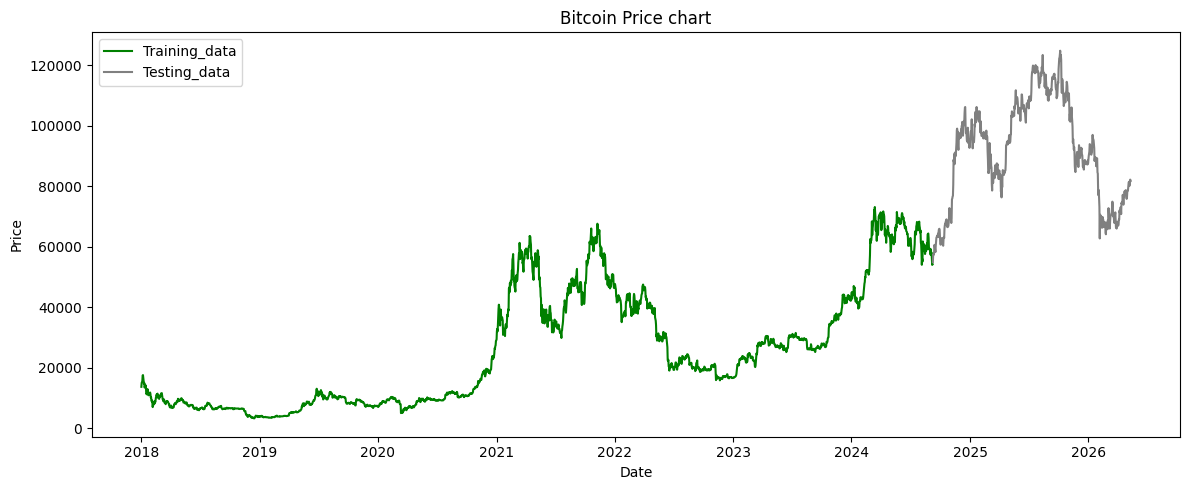

In [40]:
# Plot train and test split of BTC price data

plt.figure(figsize=(12,5))
plt.plot(btc_sarima[:int(len(btc_sarima) * 0.8)], label='Training_data', color='green')
plt.plot(btc_sarima[int(len(btc_sarima) * 0.8):], label='Testing_data', color='grey')
plt.title("Bitcoin Price chart")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Performing step-by-step SARIMA forecasting by updating the model with each new test value
prediction_sarima = []
train_sar = train_sarima.copy()

for i in range(len(test_sarima)):
    model_sarima = SARIMAX(
        train_sar,
        order=sarima_auto.order,
        seasonal_order=sarima_auto.seasonal_order
    )
    sarima_fit = model_sarima.fit(disp=False)
    output = sarima_fit.forecast()
    yhat = output[0]
    prediction_sarima.append(yhat)
    train_sar.append(test_sarima[i])

In [42]:
print(sarima_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3663
Model:               SARIMAX(1, 1, 0)   Log Likelihood              -32111.974
Date:                Wed, 13 May 2026   AIC                          64227.948
Time:                        06:32:01   BIC                          64240.359
Sample:                             0   HQIC                         64232.367
                               - 3663                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0461      0.011     -4.307      0.000      -0.067      -0.025
sigma2      2.422e+06   1.43e+04    168.835      0.000    2.39e+06    2.45e+06
Ljung-Box (L1) (Q):                   0.02   Jarque-

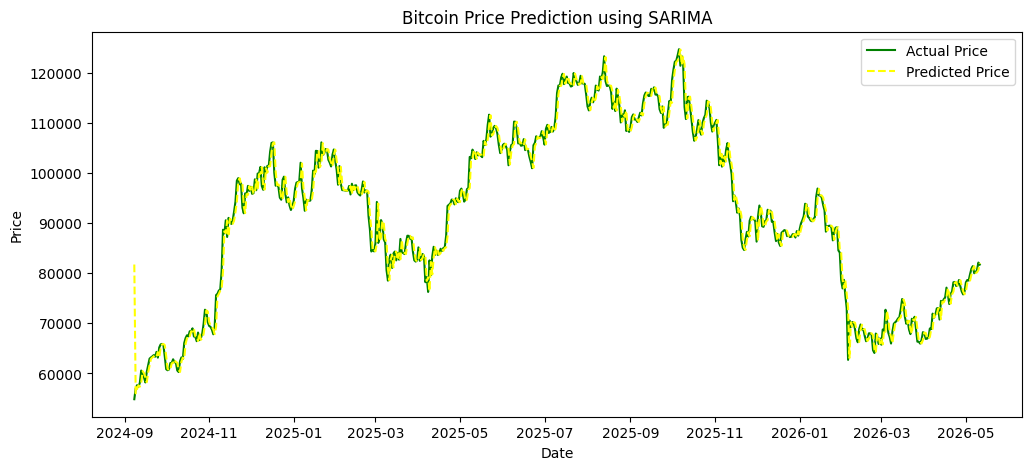

In [43]:
# Plotting actual vs predicted Bitcoin prices using SARIMA on the test dataset
plt.figure(figsize=(12,5))
plt.plot(btc_sarima[int(len(btc_sarima) * 0.8):].index, test_sarima, label='Actual Price', color='green')
plt.plot(btc_sarima[int(len(btc_sarima) * 0.8):].index, prediction_sarima, label='Predicted Price', linestyle='dashed', color='yellow')
plt.title("Bitcoin Price Prediction using SARIMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [44]:
y_true_sarima = np.array(test_sarima)
y_pred_sarima = np.array(prediction_sarima)

# 1. Mean Squared Error (MSE)
mse_sarima = mean_squared_error(y_true_sarima, y_pred_sarima)
# 2. Root Mean Squared Error (RMSE)
rmse_sarima = np.sqrt(mse_sarima)
# 3. Mean Absolute Error (MAE)
mae_sarima = mean_absolute_error(y_true_sarima, y_pred_sarima)
# 4. Mean Absolute Percentage Error (MAPE)
mape_sarima = np.mean(np.abs((y_true_sarima - y_pred_sarima) / y_true_sarima)) * 100
# 5. R² Score
r2_sarima = r2_score(y_true_sarima, y_pred_sarima)

# Print results
print(f"MSE: {mse_sarima}")
print(f"RMSE: {rmse_sarima}")
print(f"MAE: {mae_sarima}")
print(f"MAPE: {mape_sarima}%")
print(f"R2 Score: {r2_sarima}")

MSE: 5571095.666115895
RMSE: 2360.3168571435267
MAE: 1546.9356706327997
MAPE: 1.7556358953746152%
R2 Score: 0.9807980931077623


In [45]:
sarima_forecast_30 = sarima_fit.forecast(steps=30)

In [ ]:
# Creating future date range for the next 30 days.
sarima_last_date = btc_sarima.index[-1]
future_dates_sarima = pd.date_range(start=sarima_last_date, periods=31, freq='D')[1:]

In [ ]:
sarima_forecast_df = pd.DataFrame({
    'Date': future_dates_sarima,
    'Forecast': sarima_forecast_30
})

In [ ]:
sarima_forecast_df.set_index('Date', inplace=True)

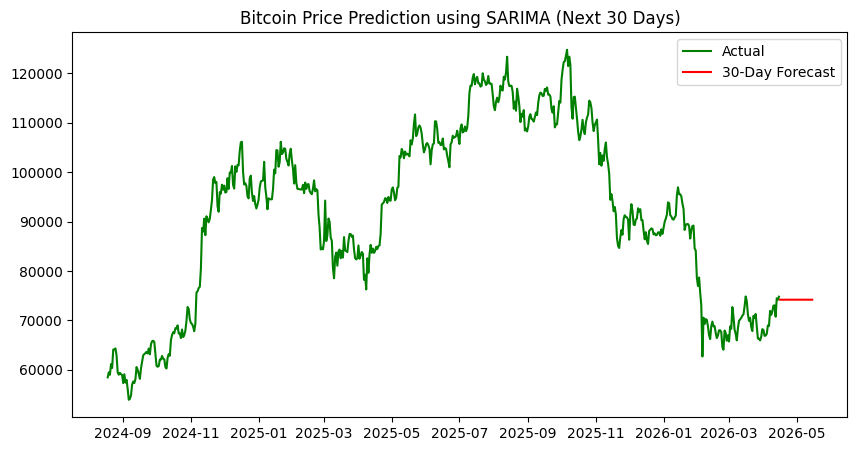

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(btc_sarima[int(len(btc_sarima) * 0.8):]['close'], label='Actual', color='green')
plt.plot(sarima_forecast_df['Forecast'], label='30-Day Forecast', color='red')

plt.legend()
plt.title("Bitcoin Price Prediction using SARIMA (Next 30 Days)")
plt.show()

The 30-day forecast graph shows that the SARIMA model predicts a relatively stable future trend. The forecast appears flat because SARIMA mainly captures historical seasonal and linear patterns from past observations. Since the recent Bitcoin prices do not show a strong upward or downward trend at the end of the dataset, the model predicts future values close to the recent average level.

# **CRYPTOCURRENCY PRICE PREDICTION USING PROPHET MODEL**

Prophet is a time series forecasting model developed by Facebook (Meta) that is used to predict future values based on historical data. It works by breaking data into key components like trend, seasonality, and noise, making it very effective for real-world data such as stock or cryptocurrency prices.

It is easy to use, handles missing data well, and provides future predictions along with confidence intervals, which helps in understanding uncertainty in forecasts.

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics


In [ ]:
btc_pro = pd.DataFrame({
    'y': btc['Close']['BTC-USD'],
    'volume': btc['Volume']['BTC-USD']
}).reset_index().rename(columns={'Date': 'ds'})
btc_pro.head()

,ds,y,volume
0,2018-01-01,13657.200195,10291200000
1,2018-01-02,14982.099609,16846600192
2,2018-01-03,15201.000000,16871900160
3,2018-01-04,15599.200195,21783199744
4,2018-01-05,17429.500000,23840899072


In [ ]:
btc_pro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3027 entries, 0 to 3026
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      3027 non-null   datetime64[ns]
 1   y       3027 non-null   float64       
 2   volume  3027 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 71.1 KB


In [ ]:
btc_pro.duplicated().sum()

np.int64(0)

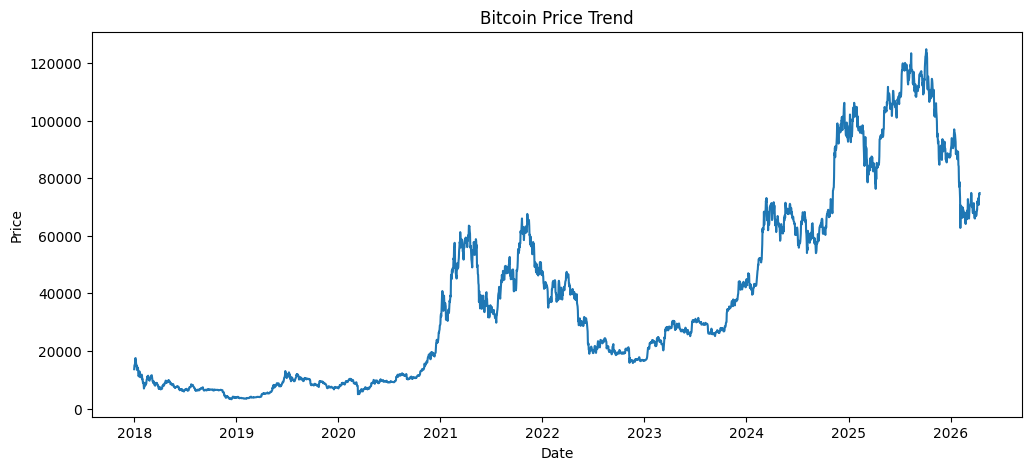

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(btc_pro['ds'], btc_pro['y'])
plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
# Creating Prophet model and adding volume as an extra feature
model_pro = Prophet(
    changepoint_prior_scale=0.5,
    daily_seasonality=True,
    yearly_seasonality=True
)
model_pro.add_regressor('volume')

In [ ]:
# Training the Prophet model on Bitcoin price data
model_pro_fit = model_pro.fit(btc_pro)

In [ ]:
# Creating future date range for the next 30 days.
future_pred = model_pro_fit.make_future_dataframe(periods=30)
future_pred['volume'] = btc_pro['volume'].mean()

In [ ]:
forecast = model_pro_fit.predict(future_pred)

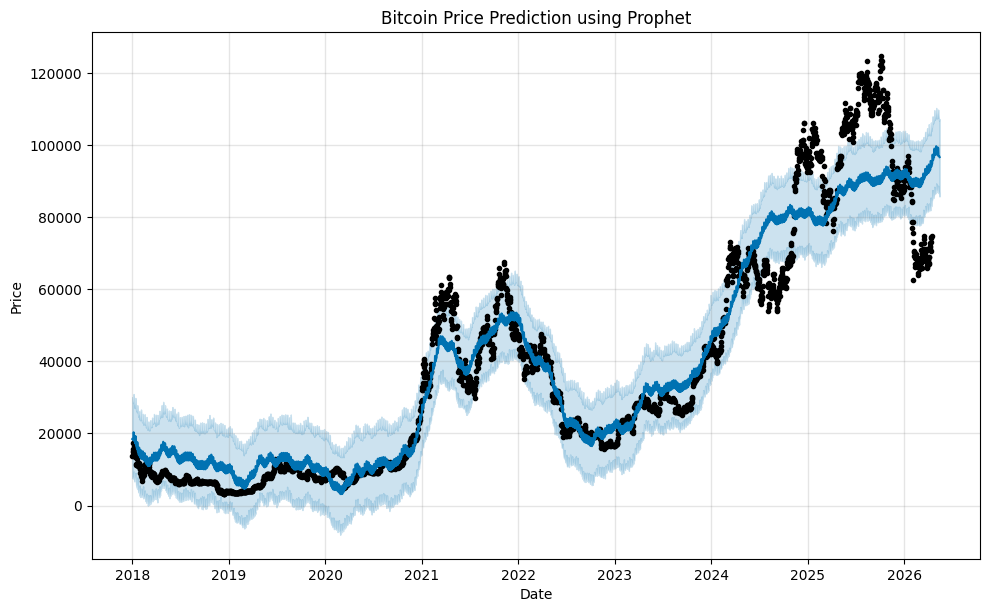

In [ ]:
# Plotting Bitcoin price predictions generated by the Prophet model

model_pro_fit.plot(forecast)
plt.title("Bitcoin Price Prediction using Prophet")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

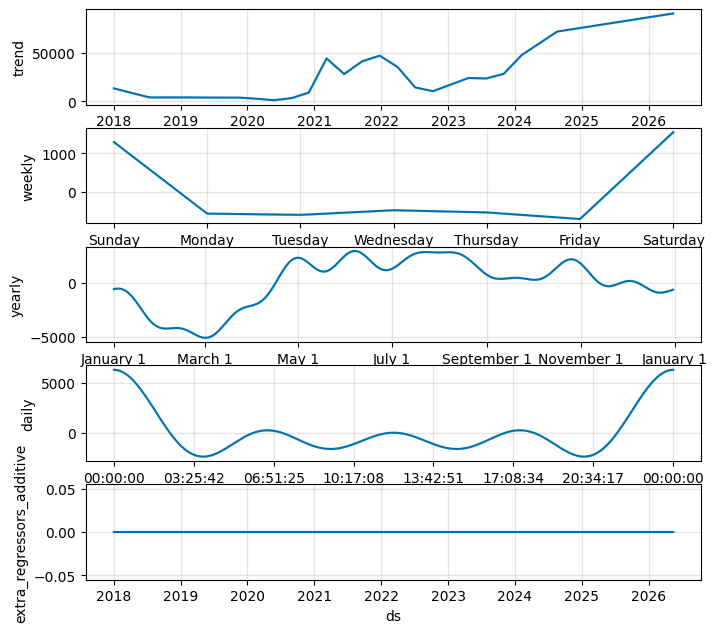

In [ ]:
# Plotting Prophet model components
fig=model_pro_fit.plot_components(forecast)
fig.set_size_inches(7,6)
plt.show()

The Prophet trend component shows that the overall Bitcoin price trend is increasing over time, indicating long-term market growth. The weekly seasonality pattern suggests that Bitcoin prices generally decrease from Sunday to Monday, remain relatively stable from Monday to Friday, and then start increasing again from Friday to Saturday.

The yearly seasonality analysis indicates that Bitcoin prices tend to rise during the period from March to May, showing stronger market performance during these months. These patterns demonstrate that the Prophet model successfully captured both long-term trends and seasonal behavior in Bitcoin price movements.

In [ ]:
# Performing cross-validation to evaluate Prophet model forecasting performance
btc_pro_cv = cross_validation(
    model_pro_fit,
    initial='730 days',
    period='30 days',
    horizon='30 days'
)

INFO:prophet:Making 76 forecasts with cutoffs between 2020-01-17 00:00:00 and 2026-03-16 00:00:00


  0%|          | 0/76 [00:00<?, ?it/s]

In [ ]:
btc_pro_perf = performance_metrics(btc_pro_cv)

In [ ]:
btc_pro_perf

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,8.988594e+07,9480.819436,5764.453965,0.109301,0.089100,0.107985,0.403509
1,4 days,9.437572e+07,9714.716658,5988.293246,0.115730,0.089100,0.114455,0.385965
2,5 days,1.015621e+08,10077.802464,6242.878006,0.122412,0.093124,0.120736,0.372807
3,6 days,1.073107e+08,10359.089953,6422.166102,0.126694,0.093124,0.124708,0.346491
4,7 days,1.112891e+08,10549.365317,6544.365007,0.129525,0.093350,0.127349,0.333333
5,8 days,1.132402e+08,10641.435964,6639.021608,0.133788,0.092311,0.131699,0.333333
6,9 days,1.177230e+08,10850.023485,6839.287472,0.140410,0.100555,0.138662,0.346491
7,10 days,1.253471e+08,11195.853300,7161.930397,0.150734,0.112242,0.148539,0.359649
8,11 days,1.309480e+08,11443.251809,7457.724265,0.159101,0.121228,0.156711,0.350877
9,12 days,1.367888e+08,11695.673469,7799.109020,0.169372,0.139041,0.166161,0.324561


Cross-validation results show that forecasting error gradually increases as the prediction horizon becomes larger. For shorter forecasting periods (3–7 days), the model achieved lower RMSE and MAE values, indicating better prediction accuracy. However, for longer forecasting periods (20–30 days), the errors increased because Bitcoin prices are highly volatile and difficult to predict over longer durations.

# **PREDICTION USING LSTM**

Long Short-Term Memory (LSTM) is a deep learning model specially designed for sequential a data. The model processes previous price sequences to capture both short-term fluctuations and long-term trends in the market. Data normalization and sequence generation techniques are applied before training to improve model performance and prediction accuracy.

The trained LSTM model is then used to forecast future Bitcoin prices and compare the predicted values with actual market prices.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [ ]:
btc_lstm = pd.DataFrame({
    'close': btc['Close']['BTC-USD']
})

In [ ]:
# LSTM are sensitive to the scale of the data, so i apply MinMax scaler.
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(btc_lstm['close'].values.reshape(-1,1))

In [ ]:
# Function to create input sequences and target values for LSTM model training
def create_dataset(data, time_step=60):
    X, Y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        Y.append(data[i+time_step, 0])
    return np.array(X), np.array(Y)

X, Y = create_dataset(scaled_data, time_step=100)

In [ ]:
# Reshaping input data into 3D format required for LSTM model training
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
# Create train test data
train_size = int(len(X)*0.8)

x_train, x_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2340, 100, 1), (586, 100, 1), (2340,), (586,))

In [ ]:
# Creating and compiling the LSTM model
model = Sequential()

model.add(LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1), activation='relu'))
model.add(Dropout(0.2))
model.add(LSTM(60, return_sequences=True, activation='relu'))
model.add(Dropout(0.2))
model.add(LSTM(30, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Training the LSTM model using training data and validating on test data
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - loss: 0.0184 - val_loss: 0.0361
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - loss: 0.0030 - val_loss: 0.0051
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - loss: 0.0023 - val_loss: 0.0079
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - loss: 0.0021 - val_loss: 0.0085
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - loss: 0.0020 - val_loss: 0.0031
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - loss: 0.0019 - val_loss: 0.0029
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - loss: 0.0017 - val_loss: 0.0063
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - loss: 0.0015 - val_loss: 0.0052


In [ ]:
train_predict=model.predict(x_train)
test_predict=model.predict(x_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


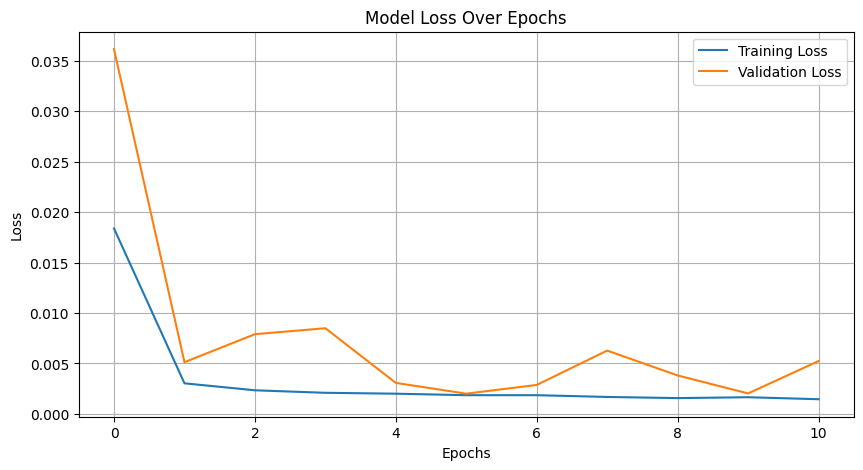

In [ ]:
# Plotting training and validation loss to evaluate LSTM model performance during training
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

In [ ]:
train_predict.shape, test_predict.shape

((2340, 1), (586, 1))

In [ ]:
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [ ]:
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
y_train_actual.shape, y_test_actual.shape

((2340, 1), (586, 1))

In [ ]:
# for Training data

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_train_actual, train_predict)
# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train_actual, train_predict)
# 4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_train_actual - train_predict) / y_train_actual)) * 100
# 5. R² Score
r2 = r2_score(y_train_actual, train_predict)

# Print results
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"R2 Score: {r2}")

MSE: 8161623.256942719
RMSE: 2856.8554840843312
MAE: 1946.6087262536726
MAPE: 8.868579234759878%
R2 Score: 0.9783710188916751


In [ ]:
# for test data

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test_actual, test_predict)
# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
# 3. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_actual, test_predict)
# 4. Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test_actual - test_predict) / y_test_actual)) * 100
# 5. R² Score
r2 = r2_score(y_test_actual, test_predict)

# Print results
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"R2 Score: {r2}")

MSE: 29660017.85053084
RMSE: 5446.101160512063
MAE: 4200.932153903584
MAPE: 4.643120715616011%
R2 Score: 0.9004826362647407


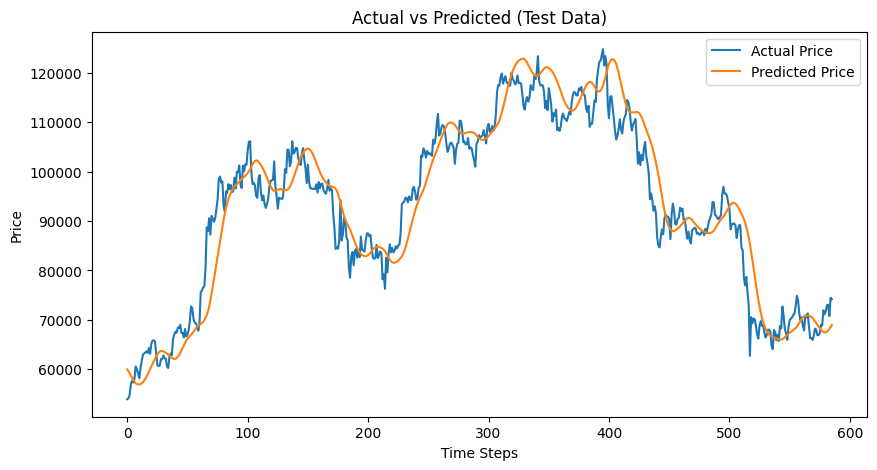

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(test_predict, label='Predicted Price')

plt.title('Actual vs Predicted (Test Data)')
plt.xlabel('Time Steps')
plt.ylabel('Price')

plt.legend()
plt.show()

In [ ]:
lstm_last_date = btc_lstm.index[-1]
future_dates_lstm = pd.date_range(start=lstm_last_date, periods=31, freq='D')[1:]

In [ ]:
def make_prediction():
  prediction_30 = []
  x = btc_lstm['close'][-100:].values.tolist()

  for i in range(0, 30):
    current_sequence_for_scaling = np.array(x[-100:]).reshape(-1, 1)
    scaled_input_for_model = scaler.transform(current_sequence_for_scaling)
    input_for_predict = scaled_input_for_model.reshape(1, 100, 1)

    pred_scaled_value = model.predict(input_for_predict, verbose=0) # Predict scaled value

    # Inverse transform the predicted scaled value to get the actual price
    # This actual price is appended to x for the next iteration
    pred_actual_value = scaler.inverse_transform(pred_scaled_value)[0][0]
    prediction_30.append(pred_actual_value)
    x.append(pred_actual_value) # Append actual price to maintain unscaled sequence

  return prediction_30 # Return list of scaled predictions


In [ ]:
yum = make_prediction()

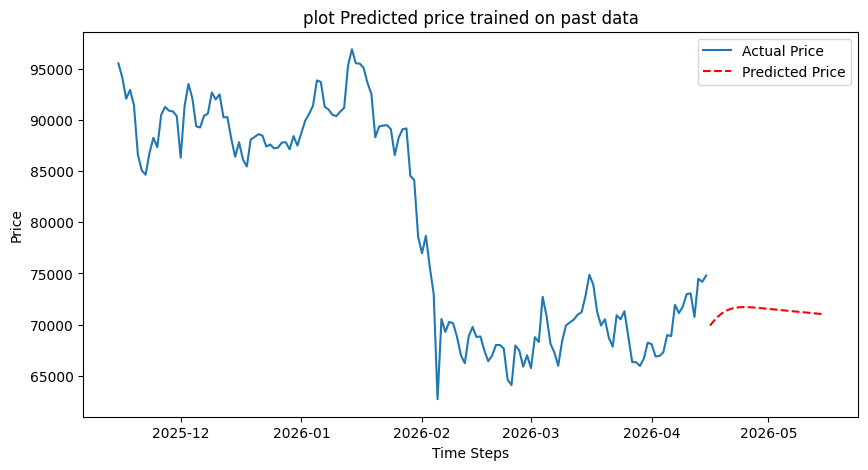

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(btc_lstm[int(len(btc_lstm)*0.95) : ]['close'], label='Actual Price')
plt.plot(future_dates_lstm, yum, label='Predicted Price', linestyle='dashed', color='red')

plt.title('plot Predicted price trained on past data')
plt.xlabel('Time Steps')
plt.ylabel('Price')

plt.legend()
plt.show()

The predicted values show a relatively stable trend around the recent market price range. The model forecasts a slight downward movement after a small increase, indicating that the LSTM model expects the Bitcoin price to remain relatively stable in the near future without major fluctuations.

# **CONCLUSION**

This project focused on predicting Bitcoin prices using different time series and deep learning models, including ARIMA, SARIMA, Prophet, and LSTM. Historical Bitcoin price data from Yahoo Finance was analyzed to understand market trends, volatility, and seasonal patterns.

Exploratory Data Analysis (EDA) showed that Bitcoin prices are highly volatile and influenced by both short-term fluctuations and long-term trends. Additional features such as moving averages and daily returns helped improve the understanding of market behavior.

Among the models, ARIMA and SARIMA performed well for short-term forecasting and captured historical price patterns effectively. The Prophet model successfully identified long-term trends and seasonal behavior, while the LSTM model demonstrated the ability to learn complex patterns from sequential data and provide smooth future predictions.